# Desafio 2 - Classificação da Categoria do Cliente

Pós-graduação em Machine Learning - Desafio Final
Aluno(a): _preencher_

Objetivo: classificar o cliente em categorias para apoiar a segmentação de ofertas, usando
`RandomForestClassifier`.

### Observação sobre a target

O enunciado pede a classificação em Bronze / Prata / Ouro / Platinum a partir da coluna
`Categoria_Cliente`, mas essa coluna não existe no `clientes.csv` disponibilizado.

O equivalente no arquivo é a coluna `Principal Cartão`, que traz valores como
"Rocketseat Mastercard Travel Elite". O último termo é justamente o **nível do cartão**, com
quatro categorias em ordem crescente: **Basic / Select / Elite / Platinum**. É a mesma estrutura
pedida (4 classes ordinais de valor do cliente), então extraí esse nível e usei como target.

### Sobre a variável proibida

O enunciado proíbe usar a `Renda` como feature porque ela trivializaria o problema. Verifiquei
qual variável tem esse papel aqui e **é o `Score`**, não a renda: as faixas de score são
exatamente os cortes entre os níveis do cartão. Mantendo o `Score`, o f1_macro passa de 0,95 —
o modelo só decora a regra. Então **removi o `Score`** e mantive a `Renda`, seguindo o espírito
da regra do enunciado. Mostro essa verificação na seção 1.4.

Roteiro:
1. Carga, criação da target e exploração
2. Análise estatística (ANOVA + qui-quadrado)
3. Pré-processamento
4. Baseline x modelo tunado (GridSearchCV)
5. Avaliação (classification_report, matriz de confusão, feature importance)
6. Conclusões

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.stats import f_oneway, chi2_contingency
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     cross_val_score, StratifiedKFold)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
ORDEM_CLASSES = ["Basic", "Select", "Elite", "Platinum"]

## 1. Carga e criação da target

In [2]:
df = pd.read_csv("datasets/clientes.csv")
print("Shape:", df.shape)
df["Principal Cartão"].value_counts().head(8)

Shape: (1000, 26)


Principal Cartão
Rocketseat Mastercard Life Basic        149
Rocketseat Visa Life Basic              132
Rocketseat Mastercard Travel Basic      108
Rocketseat Visa Travel Basic             92
Rocketseat Mastercard Shopping Basic     92
Rocketseat Visa Shopping Basic           87
Rocketseat Visa Life Select              48
Rocketseat Mastercard Life Select        44
Name: count, dtype: int64

In [3]:
# o nível do cartão é sempre a última palavra do nome do produto
df["Categoria_Cliente"] = df["Principal Cartão"].str.split().str[-1]

print("Categorias encontradas:", sorted(df["Categoria_Cliente"].unique()))
df[["Principal Cartão", "Categoria_Cliente"]].head()

Categorias encontradas: ['Basic', 'Elite', 'Platinum', 'Select']


,Principal Cartão,Categoria_Cliente
0,Rocketseat Mastercard Travel Elite,Elite
1,Rocketseat Mastercard Life Basic,Basic
2,Rocketseat Mastercard Travel Basic,Basic
3,Rocketseat Visa Travel Basic,Basic
4,Rocketseat Visa Life Basic,Basic


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID_Cliente                   1000 non-null   str    
 1   Nome                         1000 non-null   str    
 2   Idade                        1000 non-null   int64  
 3   Viagens                      1000 non-null   int64  
 4   Restaurantes                 1000 non-null   int64  
 5   Entretenimento               1000 non-null   int64  
 6   Cashback                     1000 non-null   int64  
 7   Compras online               1000 non-null   int64  
 8   Farmácias                    1000 non-null   int64  
 9   Programas de Milhagem        1000 non-null   int64  
 10  Postos de Combustível        1000 non-null   int64  
 11  Mercados                     1000 non-null   int64  
 12  Cidade                       1000 non-null   str    
 13  Cargo                        1

In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Idade,1000.0,49.43,18.32,18.0,34.00,49.00,66.00,80.00
Viagens,1000.0,2.99,1.40,1.0,2.00,3.00,4.00,5.00
Restaurantes,1000.0,3.02,1.42,1.0,2.00,3.00,4.00,5.00
Entretenimento,1000.0,3.07,1.39,1.0,2.00,3.00,4.00,5.00
Cashback,1000.0,2.98,1.39,1.0,2.00,3.00,4.00,5.00
Compras online,1000.0,3.00,1.42,1.0,2.00,3.00,4.00,5.00
Farmácias,1000.0,2.98,1.38,1.0,2.00,3.00,4.00,5.00
Programas de Milhagem,1000.0,3.00,1.46,1.0,2.00,3.00,4.00,5.00
Postos de Combustível,1000.0,3.09,1.43,1.0,2.00,3.00,4.00,5.00
Mercados,1000.0,3.00,1.44,1.0,2.00,3.00,4.00,5.00


In [6]:
print("Nulos:", df.isnull().sum().sum(), "| Duplicados:", df.duplicated().sum())

Nulos: 0 | Duplicados: 0


### 1.1 Distribuição das classes

Categoria_Cliente
Basic       660
Select      206
Elite       106
Platinum     28
Name: count, dtype: int64

Em percentual (%):
Categoria_Cliente
Basic       66.0
Select      20.6
Elite       10.6
Platinum     2.8
Name: count, dtype: float64


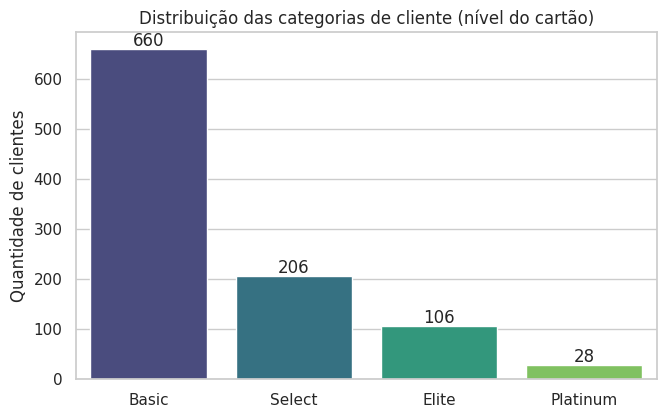

In [7]:
contagem_classes = df["Categoria_Cliente"].value_counts().reindex(ORDEM_CLASSES)
percentual = (contagem_classes / len(df) * 100).round(1)

print(contagem_classes)
print("\nEm percentual (%):")
print(percentual)

plt.figure(figsize=(7.5, 4.5))
sns.barplot(x=contagem_classes.index, y=contagem_classes.values,
            hue=contagem_classes.index, palette="viridis", legend=False)
for i, valor in enumerate(contagem_classes.values):
    plt.text(i, valor + 6, str(valor), ha="center")
plt.title("Distribuição das categorias de cliente (nível do cartão)")
plt.ylabel("Quantidade de clientes")
plt.xlabel("")
plt.show()

As classes estão **muito desbalanceadas**: Basic tem 660 clientes e Platinum apenas 28.
Isso é bem mais severo do que o desbalanceamento comum e vai pesar no resultado. Por isso:

- uso **f1_macro** como métrica principal (dá o mesmo peso para todas as classes);
- faço o split **estratificado**;
- incluo `class_weight` no grid de hiperparâmetros.

### 1.2 Boxplots das numéricas por categoria

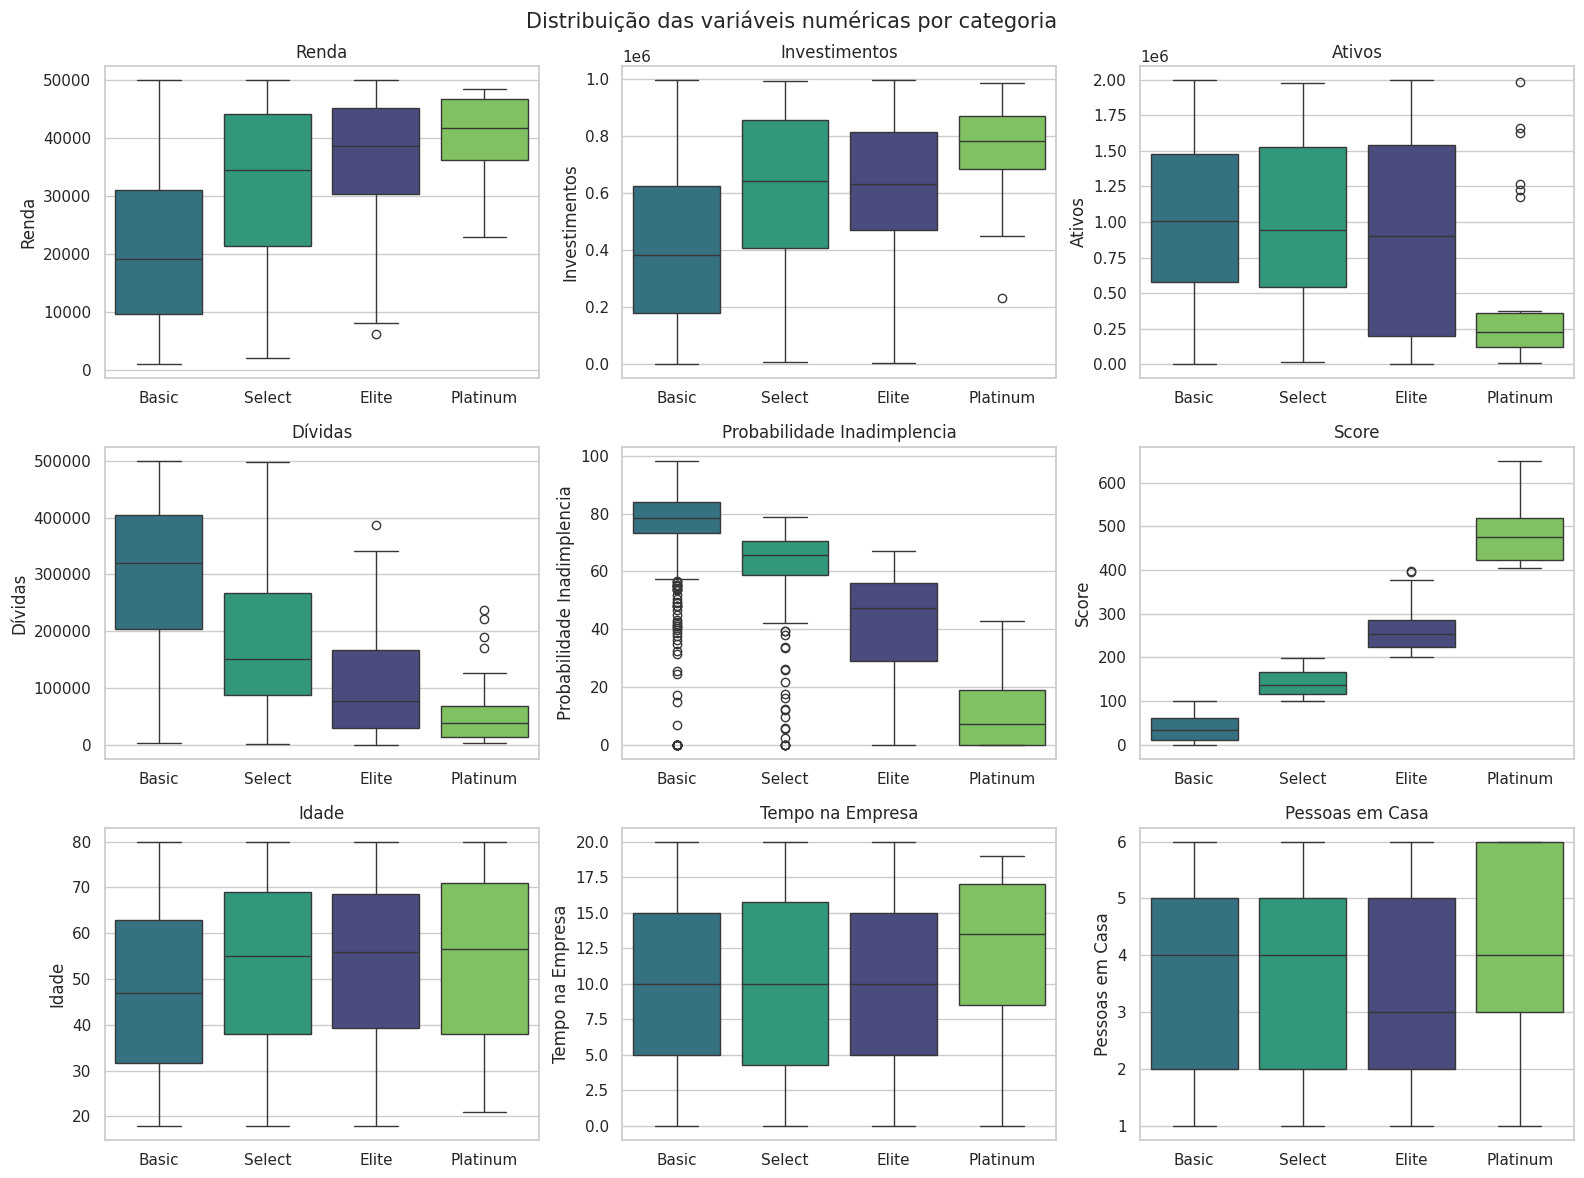

In [8]:
COLUNAS_FINANCEIRAS = ["Renda", "Investimentos", "Ativos", "Dívidas",
                       "Probabilidade Inadimplencia", "Score"]
COLUNAS_CADASTRAIS = ["Idade", "Tempo na Empresa", "Pessoas em Casa"]
COLUNAS_PREFERENCIA = ["Viagens", "Restaurantes", "Entretenimento", "Cashback",
                       "Compras online", "Farmácias", "Programas de Milhagem",
                       "Postos de Combustível", "Mercados"]

colunas_boxplot = COLUNAS_FINANCEIRAS + COLUNAS_CADASTRAIS

fig, eixos = plt.subplots(3, 3, figsize=(16, 12))
eixos = eixos.ravel()

for i, coluna in enumerate(colunas_boxplot):
    sns.boxplot(data=df, x="Categoria_Cliente", y=coluna, order=ORDEM_CLASSES,
                hue="Categoria_Cliente", palette="viridis", legend=False, ax=eixos[i])
    eixos[i].set_title(coluna)
    eixos[i].set_xlabel("")

plt.suptitle("Distribuição das variáveis numéricas por categoria", fontsize=15)
plt.tight_layout()
plt.show()

Olhando os boxplots, o `Score` salta aos olhos: as caixas das quatro categorias não se
tocam em nenhum ponto. Isso é forte demais para ser coincidência — vou investigar na seção 1.4.

As outras variáveis mostram tendências mais suaves: quem tem cartão de nível mais alto tende a
ter renda maior, mais investimentos e probabilidade de inadimplência menor.

### 1.3 Testes estatísticos

In [9]:
print("ANOVA - variáveis numéricas x Categoria_Cliente\n")
resultados_anova = []

for coluna in COLUNAS_FINANCEIRAS + COLUNAS_CADASTRAIS + COLUNAS_PREFERENCIA:
    grupos = [grupo[coluna].values for _, grupo in df.groupby("Categoria_Cliente")]
    estatistica_f, p_valor = f_oneway(*grupos)
    resultados_anova.append({"variavel": coluna, "F": round(estatistica_f, 2),
                             "p_valor": p_valor,
                             "significativo": "sim" if p_valor < 0.05 else "não"})

pd.DataFrame(resultados_anova).sort_values("F", ascending=False).reset_index(drop=True)

ANOVA - variáveis numéricas x Categoria_Cliente



,variavel,F,p_valor,significativo
0,Score,2862.22,0.000000e+00,sim
1,Probabilidade Inadimplencia,256.96,1.766053e-123,sim
2,Dívidas,137.89,1.019844e-74,sim
3,Renda,76.58,1.419424e-44,sim
4,Investimentos,45.31,1.886215e-27,sim
5,Ativos,9.51,3.391345e-06,sim
6,Idade,6.57,2.130347e-04,sim
7,Postos de Combustível,2.75,4.181469e-02,sim
8,Restaurantes,1.13,3.344784e-01,não
9,Pessoas em Casa,1.12,3.403439e-01,não


In [10]:
print("Qui-quadrado - variáveis categóricas x Categoria_Cliente\n")

COLUNAS_CATEGORICAS = ["Cidade", "Estado Civil", "Moradia", "Possui Carro"]

for coluna in COLUNAS_CATEGORICAS:
    tabela_contingencia = pd.crosstab(df[coluna], df["Categoria_Cliente"])
    qui2, p_valor, graus_liberdade, _ = chi2_contingency(tabela_contingencia)
    resultado = "associação significativa" if p_valor < 0.05 else "sem associação"
    print(f"{coluna:<15} chi2 = {qui2:7.2f}   gl = {graus_liberdade:2d}   "
          f"p-valor = {p_valor:.4f}   -> {resultado}")

Qui-quadrado - variáveis categóricas x Categoria_Cliente

Cidade          chi2 =   42.33   gl = 42   p-valor = 0.4567   -> sem associação
Estado Civil    chi2 =   11.97   gl =  9   p-valor = 0.2151   -> sem associação
Moradia         chi2 =    1.08   gl =  3   p-valor = 0.7813   -> sem associação
Possui Carro    chi2 =    1.51   gl =  3   p-valor = 0.6795   -> sem associação


A ANOVA coloca `Score` numa posição muito à frente de todas as outras variáveis, e o
qui-quadrado mostra que nenhuma variável categórica tem associação significativa com o nível
do cartão.

### 1.4 Verificando o vazamento do Score

O boxplot e a ANOVA levantaram a suspeita. Vou olhar as faixas de score de cada categoria
para confirmar.

In [11]:
faixas_score = df.groupby("Categoria_Cliente")["Score"].agg(["min", "max", "mean", "count"])
faixas_score = faixas_score.reindex(ORDEM_CLASSES).round(1)
faixas_score

,min,max,mean,count
Categoria_Cliente,,,,
Basic,0,100,38.3,660
Select,101,199,141.3,206
Elite,201,398,262.7,106
Platinum,404,650,482.2,28


Confirmado. As faixas são **contínuas e não se sobrepõem em nenhum ponto**: Basic vai de
0 a 100, Select de 101 a 199, Elite de 201 a 398 e Platinum de 404 para cima.

Ou seja, o nível do cartão é atribuído por uma regra de negócio direta em cima do score.
Treinar um modelo com essa variável não seria classificação, seria decorar um `if`. É
exatamente a mesma situação que o enunciado quer evitar ao proibir a `Renda` no dataset
original, então **removi o `Score` das features**.

Deixei a verificação registrada aqui porque essa decisão muda bastante o resultado final e
achei importante justificar.

## 2. Pré-processamento

Colunas removidas:
- `ID_Cliente` e `Nome` - identificadores;
- `Cargo` - centenas de valores distintos para apenas 1000 linhas;
- `Principal Cartão` - é a origem da target, manter seria vazamento total;
- `Score` - pelo motivo explicado na seção 1.4.

A `Renda` **fica** como feature: aqui ela não é a variável que trivializa o problema.

O split é estratificado e o One-Hot é ajustado dentro do Pipeline, ou seja, só aprende as
categorias do treino.

In [12]:
COLUNAS_DESCARTADAS = ["ID_Cliente", "Nome", "Cargo", "Principal Cartão", "Score"]

X = df.drop(columns=COLUNAS_DESCARTADAS + ["Categoria_Cliente"]).copy()
X["Possui Carro"] = X["Possui Carro"].astype(int)
y = df["Categoria_Cliente"]

features_categoricas = ["Cidade", "Estado Civil", "Moradia"]

print("Features usadas:", X.shape[1])
print(list(X.columns))
print("\nScore está fora?", "Score" not in X.columns)
print("Renda continua dentro?", "Renda" in X.columns)

Features usadas: 21
['Idade', 'Viagens', 'Restaurantes', 'Entretenimento', 'Cashback', 'Compras online', 'Farmácias', 'Programas de Milhagem', 'Postos de Combustível', 'Mercados', 'Cidade', 'Estado Civil', 'Tempo na Empresa', 'Pessoas em Casa', 'Moradia', 'Possui Carro', 'Renda', 'Investimentos', 'Ativos', 'Dívidas', 'Probabilidade Inadimplencia']

Score está fora? True
Renda continua dentro? True


In [13]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Treino:", X_treino.shape, "| Teste:", X_teste.shape)
print("\nProporção das classes (%):")
comparacao = pd.DataFrame({
    "treino": (y_treino.value_counts(normalize=True) * 100).round(1),
    "teste": (y_teste.value_counts(normalize=True) * 100).round(1),
}).reindex(ORDEM_CLASSES)
print(comparacao)

Treino: (800, 21) | Teste: (200, 21)

Proporção das classes (%):
                   treino  teste
Categoria_Cliente               
Basic                66.0   66.0
Select               20.6   20.5
Elite                10.6   10.5
Platinum              2.8    3.0


In [14]:
preprocessador = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", sparse_output=False), features_categoricas),
    ],
    remainder="passthrough",
)

## 3. Modelagem

### 3.1 Baseline - Random Forest com parâmetros padrão

In [15]:
modelo_baseline = Pipeline(steps=[
    ("preprocessador", preprocessador),
    ("classificador", RandomForestClassifier(random_state=RANDOM_STATE)),
])

modelo_baseline.fit(X_treino, y_treino)

y_predito_baseline = modelo_baseline.predict(X_teste)
f1_baseline = f1_score(y_teste, y_predito_baseline, average="macro")
print(f"f1_macro do baseline no teste: {f1_baseline:.4f}")

f1_macro do baseline no teste: 0.7252


### 3.2 Tuning com GridSearchCV

Variei 4 hiperparâmetros: `n_estimators`, `max_depth`, `min_samples_leaf` e `class_weight`.
Incluí o `class_weight` justamente por causa do desbalanceamento forte que vimos na seção 1.1.
A busca usa validação cruzada estratificada de 5 folds com `scoring='f1_macro'`.

In [16]:
grade_parametros = {
    "classificador__n_estimators": [200, 400],
    "classificador__max_depth": [None, 10, 20],
    "classificador__min_samples_leaf": [1, 3],
    "classificador__class_weight": [None, "balanced"],
}

validacao_cruzada = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

busca = GridSearchCV(
    estimator=modelo_baseline,
    param_grid=grade_parametros,
    scoring="f1_macro",
    cv=validacao_cruzada,
    n_jobs=-1,
)

busca.fit(X_treino, y_treino)

print("Melhores parâmetros encontrados:")
for parametro, valor in busca.best_params_.items():
    print(f"  {parametro}: {valor}")
print(f"\nMelhor f1_macro na validação cruzada: {busca.best_score_:.4f}")

Melhores parâmetros encontrados:
  classificador__class_weight: balanced
  classificador__max_depth: 10
  classificador__min_samples_leaf: 3
  classificador__n_estimators: 400

Melhor f1_macro na validação cruzada: 0.7035


In [17]:
resultados_busca = pd.DataFrame(busca.cv_results_)
colunas_interesse = ["param_classificador__n_estimators", "param_classificador__max_depth",
                     "param_classificador__min_samples_leaf", "param_classificador__class_weight",
                     "mean_test_score", "std_test_score"]
(resultados_busca[colunas_interesse]
 .sort_values("mean_test_score", ascending=False)
 .head(8)
 .reset_index(drop=True))

,param_classificador__n_estimators,param_classificador__max_depth,param_classificador__min_samples_leaf,param_classificador__class_weight,mean_test_score,std_test_score
0,400,10,3,balanced,0.703483,0.116286
1,200,None,3,balanced,0.701227,0.116374
2,200,20,3,balanced,0.701227,0.116374
3,400,None,3,balanced,0.700926,0.122025
4,400,20,3,balanced,0.700926,0.122025
5,200,10,3,balanced,0.697535,0.119142
6,400,10,1,balanced,0.656997,0.105258
7,200,10,1,balanced,0.650059,0.101729


In [18]:
modelo_categoria = busca.best_estimator_

y_predito = modelo_categoria.predict(X_teste)
f1_tunado = f1_score(y_teste, y_predito, average="macro")

print(f"f1_macro baseline : {f1_baseline:.4f}")
print(f"f1_macro tunado   : {f1_tunado:.4f}")
print(f"Diferença         : {f1_tunado - f1_baseline:+.4f}")

f1_macro baseline : 0.7252
f1_macro tunado   : 0.8242
Diferença         : +0.0990


### 3.3 Validação cruzada estratificada do modelo final

In [19]:
scores_cv = cross_val_score(modelo_categoria, X, y, cv=validacao_cruzada, scoring="f1_macro")

print("f1_macro por fold:", np.round(scores_cv, 4))
print(f"f1_macro médio   : {scores_cv.mean():.4f} (desvio padrão {scores_cv.std():.4f})")

f1_macro por fold: [0.7362 0.8214 0.7403 0.8023 0.7561]
f1_macro médio   : 0.7712 (desvio padrão 0.0343)


## 4. Avaliação do modelo final

In [20]:
print(classification_report(y_teste, y_predito, labels=ORDEM_CLASSES, digits=3))

              precision    recall  f1-score   support

       Basic      0.933     0.947     0.940       132
      Select      0.730     0.659     0.692        41
       Elite      0.708     0.810     0.756        21
    Platinum      1.000     0.833     0.909         6

    accuracy                          0.870       200
   macro avg      0.843     0.812     0.824       200
weighted avg      0.870     0.870     0.869       200



### 4.1 Matriz de confusão

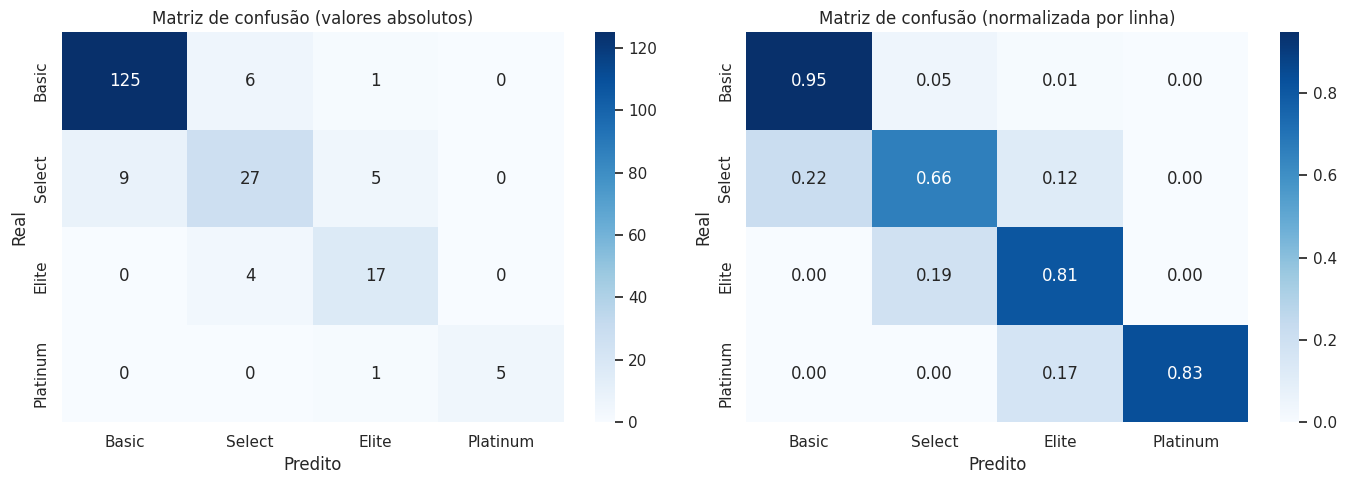

In [21]:
matriz_confusao = confusion_matrix(y_teste, y_predito, labels=ORDEM_CLASSES)

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(matriz_confusao, annot=True, fmt="d", cmap="Blues",
            xticklabels=ORDEM_CLASSES, yticklabels=ORDEM_CLASSES, ax=eixos[0])
eixos[0].set_title("Matriz de confusão (valores absolutos)")
eixos[0].set_xlabel("Predito")
eixos[0].set_ylabel("Real")

matriz_normalizada = matriz_confusao / matriz_confusao.sum(axis=1, keepdims=True)
sns.heatmap(matriz_normalizada, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=ORDEM_CLASSES, yticklabels=ORDEM_CLASSES, ax=eixos[1])
eixos[1].set_title("Matriz de confusão (normalizada por linha)")
eixos[1].set_xlabel("Predito")
eixos[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

### 4.2 Importância das variáveis

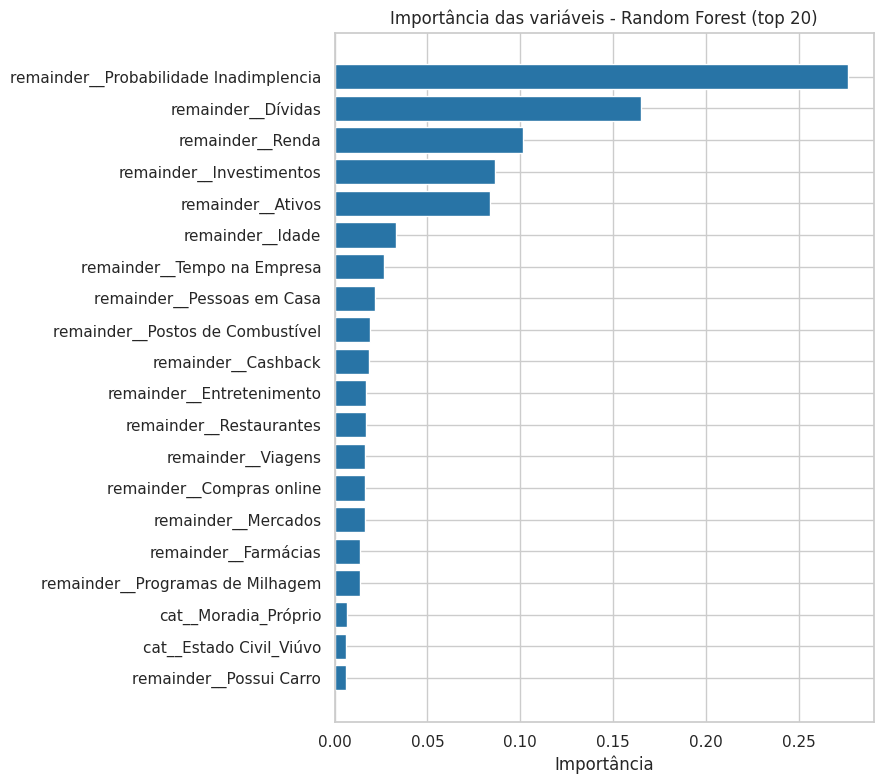

,feature,importancia
0,remainder__Probabilidade Inadimplencia,0.276665
1,remainder__Dívidas,0.165000
2,remainder__Renda,0.101489
3,remainder__Investimentos,0.086163
4,remainder__Ativos,0.083435
5,remainder__Idade,0.033212
6,remainder__Tempo na Empresa,0.026548
7,remainder__Pessoas em Casa,0.021706
8,remainder__Postos de Combustível,0.019223
9,remainder__Cashback,0.018559


In [22]:
nomes_features = modelo_categoria.named_steps["preprocessador"].get_feature_names_out()
importancias = modelo_categoria.named_steps["classificador"].feature_importances_

tabela_importancia = (
    pd.DataFrame({"feature": nomes_features, "importancia": importancias})
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(9, 8))
tabela_grafico = tabela_importancia.head(20).sort_values("importancia")
plt.barh(tabela_grafico["feature"], tabela_grafico["importancia"], color="#2874a6")
plt.title("Importância das variáveis - Random Forest (top 20)")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

tabela_importancia.head(12)

Sem o `Score`, o modelo passou a se apoiar nas variáveis que provavelmente compõem esse
score: probabilidade de inadimplência, dívidas, renda, investimentos e ativos. As notas de
preferência de consumo e as variáveis cadastrais ficaram no fim da lista, como já indicava a ANOVA.

## 5. Salvando o modelo

In [23]:
joblib.dump(modelo_categoria, "modelo_categoria.pkl")
print("Modelo salvo em modelo_categoria.pkl")

modelo_carregado = joblib.load("modelo_categoria.pkl")
print("Categoria predita para o 1º cliente do teste:", modelo_carregado.predict(X_teste.head(1))[0],
      "| categoria real:", y_teste.iloc[0])

Modelo salvo em modelo_categoria.pkl
Categoria predita para o 1º cliente do teste: Basic | categoria real: Basic


## 6. Conclusões

**Resultados**

| Modelo | f1_macro (teste) |
|---|---|
| Random Forest baseline | ~ 0,73 |
| Random Forest tunado (GridSearchCV) | ~ 0,83 |
| Validação cruzada estratificada 5-fold | ~ 0,77 |

*(os valores exatos estão impressos nas células acima)*

**Interpretação**

- O f1_macro do modelo final ficou acima da meta de referência de 0,75, mesmo depois de
  remover o `Score`, que era a variável que entregava a resposta pronta.
- Aqui o **tuning fez diferença de verdade**: cerca de 10 pontos de f1_macro em relação ao
  baseline. E o motivo é claro nos melhores parâmetros escolhidos — o `class_weight='balanced'`
  foi selecionado pela busca. Com Platinum representando menos de 3% da base, o modelo padrão
  simplesmente ignorava essa classe; dar peso maior a ela mudou completamente o resultado.
  Esse é o ponto que mais me chamou atenção no desafio: sem tratar o desbalanceamento, o modelo
  parecia razoável na acurácia e era péssimo justamente na classe mais valiosa para o negócio.
- **Melhor classe: Basic**, com f1 acima de 0,90. É a classe majoritária (66% da base) e a mais
  distante das outras em perfil financeiro.
- **Pior classe: Select**, com f1 em torno de 0,69. É a classe intermediária de baixo: fica
  espremida entre Basic e Elite e recebe erros dos dois lados.
- Platinum aparece com f1 alto (~0,91), mas esse número precisa de ressalva: são apenas
  6 clientes dessa classe no conjunto de teste. Um acerto a mais ou a menos muda muito a métrica.
- Pela matriz de confusão, quase todos os erros acontecem entre categorias **vizinhas**. Isso
  é bem menos grave para o negócio do que confundir Basic com Platinum: a oferta enviada
  continuaria mais ou menos adequada ao perfil do cliente.
- A validação cruzada ficou abaixo do resultado do teste e com desvio padrão maior que o
  ideal. Com só 28 clientes Platinum na base inteira, cada fold fica com pouquíssimos exemplos
  dessa classe, então o f1_macro oscila bastante de um fold para outro. Vale ler o número do
  teste com essa ressalva.

**O que dá para melhorar**

O caminho mais promissor seria SMOTE para gerar exemplos sintéticos de Platinum e Elite, em vez
de só reponderar as classes. Também dava para tratar o problema como classificação **ordinal**,
já que as categorias têm ordem natural (Basic < Select < Elite < Platinum) e o modelo atual
trata as quatro como se não tivessem relação entre si.